**Analyse von IOI-Verhältnissen mittels periodizitätsbasierter Proximity-Funktion:**

In diesem Abschnitt werden inter-onset intervals (IOIs) synthetisch generierter rhythmischer Sequenzen mit einer speziell entwickelten, periodizitätsbasierten Proximity-Funktion analysiert. Ziel ist es, das Ausmaß der Periodizität zwischen IOI-Paaren zu quantifizieren und systematisch über unterschiedliche rhythmische Strukturen hinweg zu vergleichen.

**Motivation und Methodik:**
Die zugrunde liegende Annahme ist, dass rhythmische Prototypen durch ganzzahlige oder einfache gebrochene Verhältnisse zwischen IOIs charakterisiert sind – etwa 1:1, 1:2, 2:3 etc. Um diese Verhältnisse als „nahe“ oder „periodisch“ zu bewerten, wurde eine neue Proximity-Funktion definiert, die auf Cosinus-Modulation basiert und frequenzselektiv mit mehreren Harmonikern arbeitet.

*Hauptmerkmale der Funktion:*
Frequenzmultiplikation: Es werden mehrere ganzzahlige Frequenzen bis zu einer einstellbaren Maximalfrequenz berücksichtigt.

*Schärfezunahme mit Frequenz:*
Höhere Frequenzen besitzen schmalere Peaks, gesteuert durch einen exponentiellen Sharpness-Term.

*Normierung:*
Die Funktion ist so skaliert, dass das Maximum immer dem gewünschten Proximity-Wert (z. B. 1.0) entspricht.

*Punktweise Maximumbildung:*
Für jedes Verhältnis wird der Maximalwert aller Frequenzantworten gewählt, um eine klare, nicht additiv überlagerte Bewertung zu erhalten.

Die Funktion erlaubt somit eine differenzierte, frequenzgewichtete und normalisierte Bewertung von IOI-Verhältnissen.

**Interaktive Exploration der Proximity-Funktion**
Über ein interaktives Widget können Parameter der Proximity-Funktion (z. B. Schärfe, Frequenzabfall, maximal zu berücksichtigende Frequenz) dynamisch verändert und die resultierende Kurve visualisiert werden. Dies erlaubt eine intuitive Erkundung der Funktion und ihrer Auswirkungen auf die Bewertung rhythmischer Verhältnisse.

In [ ]:
# Proximity Funktion mit flexibler Anpassung
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider
import numpy as np
from scipy.integrate import simpson
from scipy.stats import gaussian_kde

# Proximity-Funktion: bewertet Zahlenverhältnisse nach harmonischen Kriterien
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        # Normierung auf norm_x
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    result = np.maximum.reduce(all_freq_values)

    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# Plot-Funktion für Proximity und dessen Verteilung
def plot_proximity_max_freq(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.5,
    max_freq=6,
    weight_exponent=1.0,
    freq_sharpness_exp=0.5
):
    x_vals = np.linspace(1, 5, 1000)
    y_vals = proximity_max_freq(
        x_vals,
        sharpness_base=sharpness_base,
        sharpness_growth=sharpness_growth,
        decay=decay,
        max_freq=max_freq,
        weight_exponent=weight_exponent,
        freq_sharpness_exp=freq_sharpness_exp,
        output_max=1.0,
    )

    # Integral = numerischer Mittelwert der Funktion
    mean_prox = simpson(y_vals, x_vals) / (x_vals[-1] - x_vals[0])

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    fig.suptitle("Einfluss von Parametern auf Proximity-Funktion", fontsize=16, y=1.02)

    # Plot der Proximity-Funktion
    axes[0].plot(x_vals, y_vals, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
    axes[0].plot(
        x_vals,
        [mean_prox] * len(x_vals),
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[0].set_xlabel("x (Verhältnis)")
    axes[0].set_ylabel("Proximity")
    axes[0].set_title("Proximity mit frequenzabhängiger Sharpness")
    axes[0].set_ylim(0, 1.05)
    axes[0].grid(True, linestyle="--", alpha=0.3)
    axes[0].legend()

    # Histogramm + KDE (Verteilung von y_vals)
    counts, bins_hist, _ = axes[1].hist(
        y_vals,
        bins=50,
        range=(0, 1),
        alpha=0.4,
        color="skyblue",
        density=True,
        label="Histogramm"
    )

    kde = gaussian_kde(y_vals)
    x_dens = np.linspace(1, 2, 5000)
    kde_vals = kde(x_dens)

    # Automatische Skalierung
    scaling_factor = max(counts) / max(kde_vals)
    axes[1].plot(
        x_dens,
        kde_vals * scaling_factor,
        color="darkblue",
        lw=2,
        label="Dichte (KDE)"
    )

    axes[1].axvline(
        mean_prox,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"∫mean ≈ {mean_prox:.3f}"
    )
    axes[1].set_title("Proximity-Verteilung")
    axes[1].set_xlabel("Proximity")
    axes[1].set_ylabel("Normierte Häufigkeit")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.3)

    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()

# Interaktive Visualisierung
interact(
    plot_proximity_max_freq,
    sharpness_base=FloatSlider(min=1, max=50, step=1, value=10, description="Sharpness Base"),
    sharpness_growth=FloatSlider(min=0, max=3, step=0.1, value=2, description="Sharpness Growth"),
    decay=FloatSlider(min=0, max=3, step=0.05, value=0.1, description="Decay"),
    max_freq=IntSlider(min=1, max=12, step=1, value=4, description="Max Frequency"),
    weight_exponent=FloatSlider(min=0, max=3, step=0.1, value=1, description="Weight Exponent"),
    freq_sharpness_exp=FloatSlider(min=0, max=3, step=0.1, value=1, description="Freq Sharpness Exp"),
)


interactive(children=(FloatSlider(value=10.0, description='Sharpness Base', max=50.0, min=1.0, step=1.0), Floa…

<function __main__.plot_proximity_max_freq(sharpness_base=10.0, sharpness_growth=2.0, decay=0.5, max_freq=6, weight_exponent=1.0, freq_sharpness_exp=0.5)>

**Vergleich unterschiedlicher rhythmischer Sequenzen:**
Für eine Reihe synthetisch generierter Sequenzen aus dem Dataset *synthetic_sequences_20beats* wurden alle IOI-Verhältnisse berechnet, die Proximity-Werte ermittelt und die oberen Dreiecksmatrizen (ohne Diagonale) extrahiert. Diese wurden anschließend gruppiert nach Sequenztyp (z. B. "accelerando", "heterochron", "tempo_shift") und in einem Boxplot visualisiert.

Dies ermöglicht eine quantitative, vergleichende Analyse der Periodizitätsstruktur verschiedener rhythmischer Kategorien.

NameError: name 'simpson' is not defined

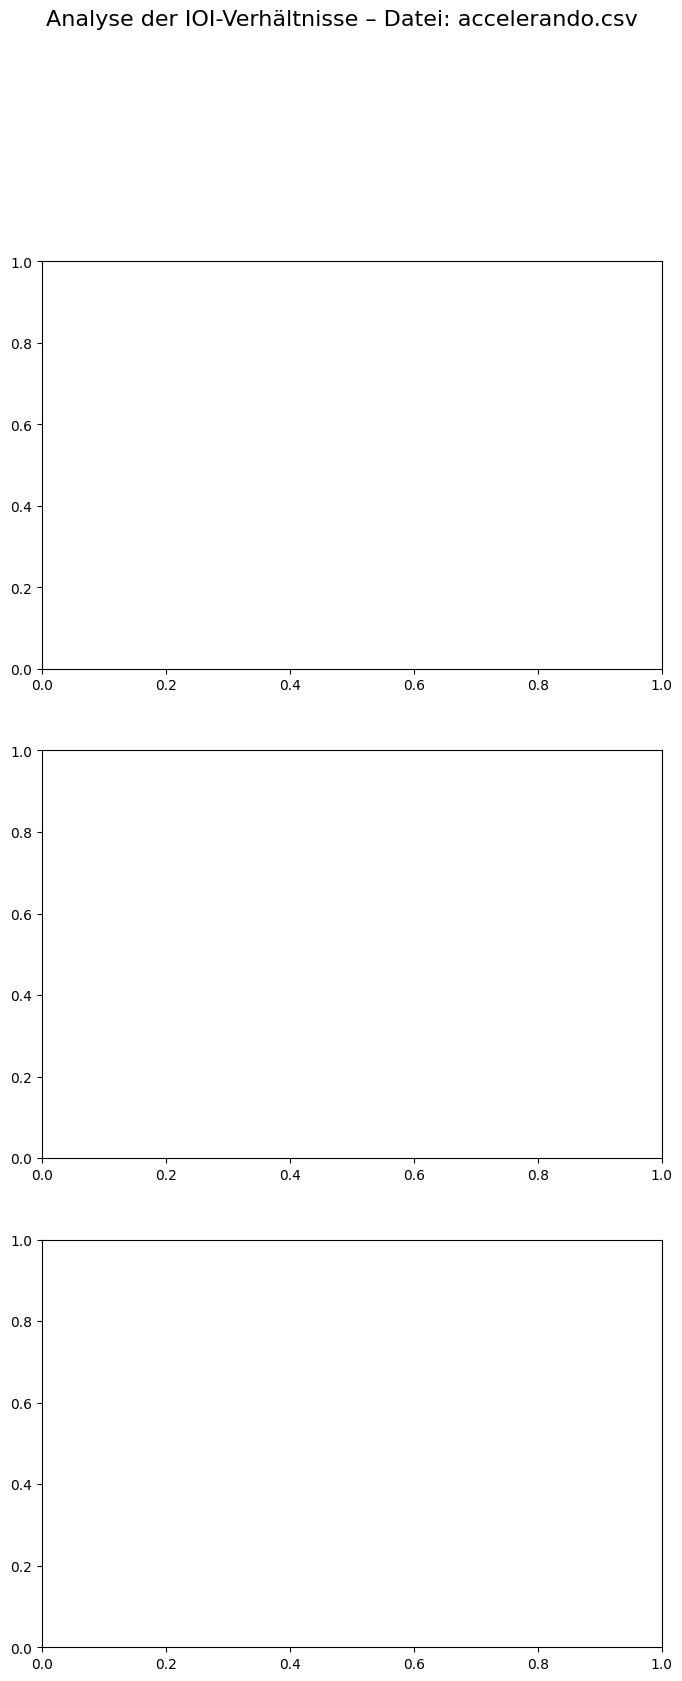

In [1]:
# Analyse von IOI-Verhältnissen (Zugriff auf Daten aus RANTO)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Neue Proximity-Funktion basierend auf vorherigem Design
def proximity_max_freq(
    x,
    sharpness_base=10.0,         # Basis-Schärfe (gilt für freq = 1)
    sharpness_growth=2.0,        # Schärfenwachstum mit x
    decay=0.1,                   # Exponentieller Abfall mit wachsendem x
    max_freq=4,                  # Höchste zu berücksichtigende Frequenz
    weight_exponent=1.0,         # Wie stark die Amplitude mit Frequenz abnimmt (1/f^exp)
    freq_sharpness_exp=1.0,      # Wie stark die Sharpness mit Frequenz wächst
    norm_x=1.0,                  # Referenzpunkt für Normierung (x, bei dem Peaks auf max gesetzt werden)
    output_max=1.0               # Maximaler Rückgabewert (Skalierung der Ausgabe)
):
    x = np.array(x)

    all_freq_values = []

    for freq in range(1, max_freq + 1):
        # --- Gewichtung der Amplitude: je höher freq, desto kleiner (1/f^weight_exponent)
        weight = 1 / (freq ** weight_exponent)

        # --- Frequenzabhängige Sharpness:
        # Sowohl die Basis-Schärfe als auch das Wachstum der Schärfe mit x steigen mit freq
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)

        # --- Gesamtschärfe für diese Frequenz und x
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)

        # --- Cosinus-basiertes Proximity-Signal (zwischen 0 und 1, scharf am Peak)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness

        # --- Normierung dieses Frequenzsignals bei norm_x, sodass Peak = 1
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value

        # --- Gewichtung & Abfall mit x
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    # --- Statt Summe oder Mittelwert wird das Maximum aller Frequenz-Werte pro x genommen
    result = np.maximum.reduce(all_freq_values)

    # --- Skalierung der maximal möglichen Ausgabe auf output_max
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# --- Daten laden
df1 = pd.read_csv("/Users/emilschmiedl/Desktop/experimenting_with_RANTO/data/iois_zusammenfassung.csv")

filename = "accelerando.csv"
condition = "20_median"

df1_match = df1[(df1["full_filename"] == filename) & (df1["condition"] == condition)]
x_vals = df1_match["ioi"].values
y_vals = df1_match["ioi"].values

# Verhältnis-Matrix
ratios = np.array([[max(x, y) / min(x, y) for x in x_vals] for y in y_vals])

# Neue Proximity-Bewertung
params = dict(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)

proximity = proximity_max_freq(ratios, **params)

# --- Für das Histogramm: Nur eindeutige Werte aus dem oberen Dreieck (ohne Diagonale)
triu_indices = np.triu_indices_from(proximity, k=1)
proximity_unique = proximity[triu_indices]

# --- Plot-Panel
fig, axes = plt.subplots(3, 1, figsize=(8, 18))
fig.suptitle(f"Analyse der IOI-Verhältnisse – Datei: {filename}", fontsize=16, y=1.02)

# Plot 1: Proximity-Funktion mit Punkten
x_range = np.linspace(1, 5, 1000)
y_curve = proximity_max_freq(x_range, **params)

# Integral (numerischer Mittelwert der Funktion über den Plotbereich)
mean_prox = simpson(y_curve, x_range) / (x_range[-1] - x_range[0])

axes[0].plot(x_range, y_curve, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
axes[0].scatter(ratios.flatten(), proximity.flatten(), color="red", s=10, alpha=0.7, label="IOI-Verhältnisse")
axes[0].set_title("Proximity-Funktion mit IOI-Verhältnissen")
axes[0].set_xlabel("Verhältnis")
axes[0].set_ylabel("Proximity")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Heatmap mit roter Linie im Farbbalken
heatmap = sns.heatmap(
    proximity * 100,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    xticklabels=list(range(1, len(iois) + 1)),
    yticklabels=list(range(1, len(iois) + 1)),
    cbar_kws={"label": "Proximity (%)"},
    vmin=0,           # Minimumwert der Farbskala
    vmax=100,         # Maximalwert der Farbskala
    ax=axes[1]
)

axes[1].invert_yaxis()

cbar = heatmap.collections[0].colorbar
cbar.ax.axhline(mean_prox * 100, color='red', linestyle='--', linewidth=2)
cbar.ax.text(0.5, mean_prox * 100, f'{mean_prox*100:.1f}%', color='red',
             va='center', ha='center', fontsize=9, backgroundcolor='white')

# Plot 3: Histogramm mit roter Linie beim Mittelwert
axes[2].hist(proximity_unique, bins=20, range=(0, 1), color='steelblue', edgecolor='black')
axes[2].axvline(mean_prox, color='red', linestyle='--', linewidth=2, label=f"∫mean ≈ {mean_prox:.3f}")
axes[2].legend()
axes[2].set_title("Histogramm der Proximity-Werte (einmalige IOI-Paare)")
axes[2].set_xlabel("Proximity")
axes[2].set_ylabel("Anzahl")

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


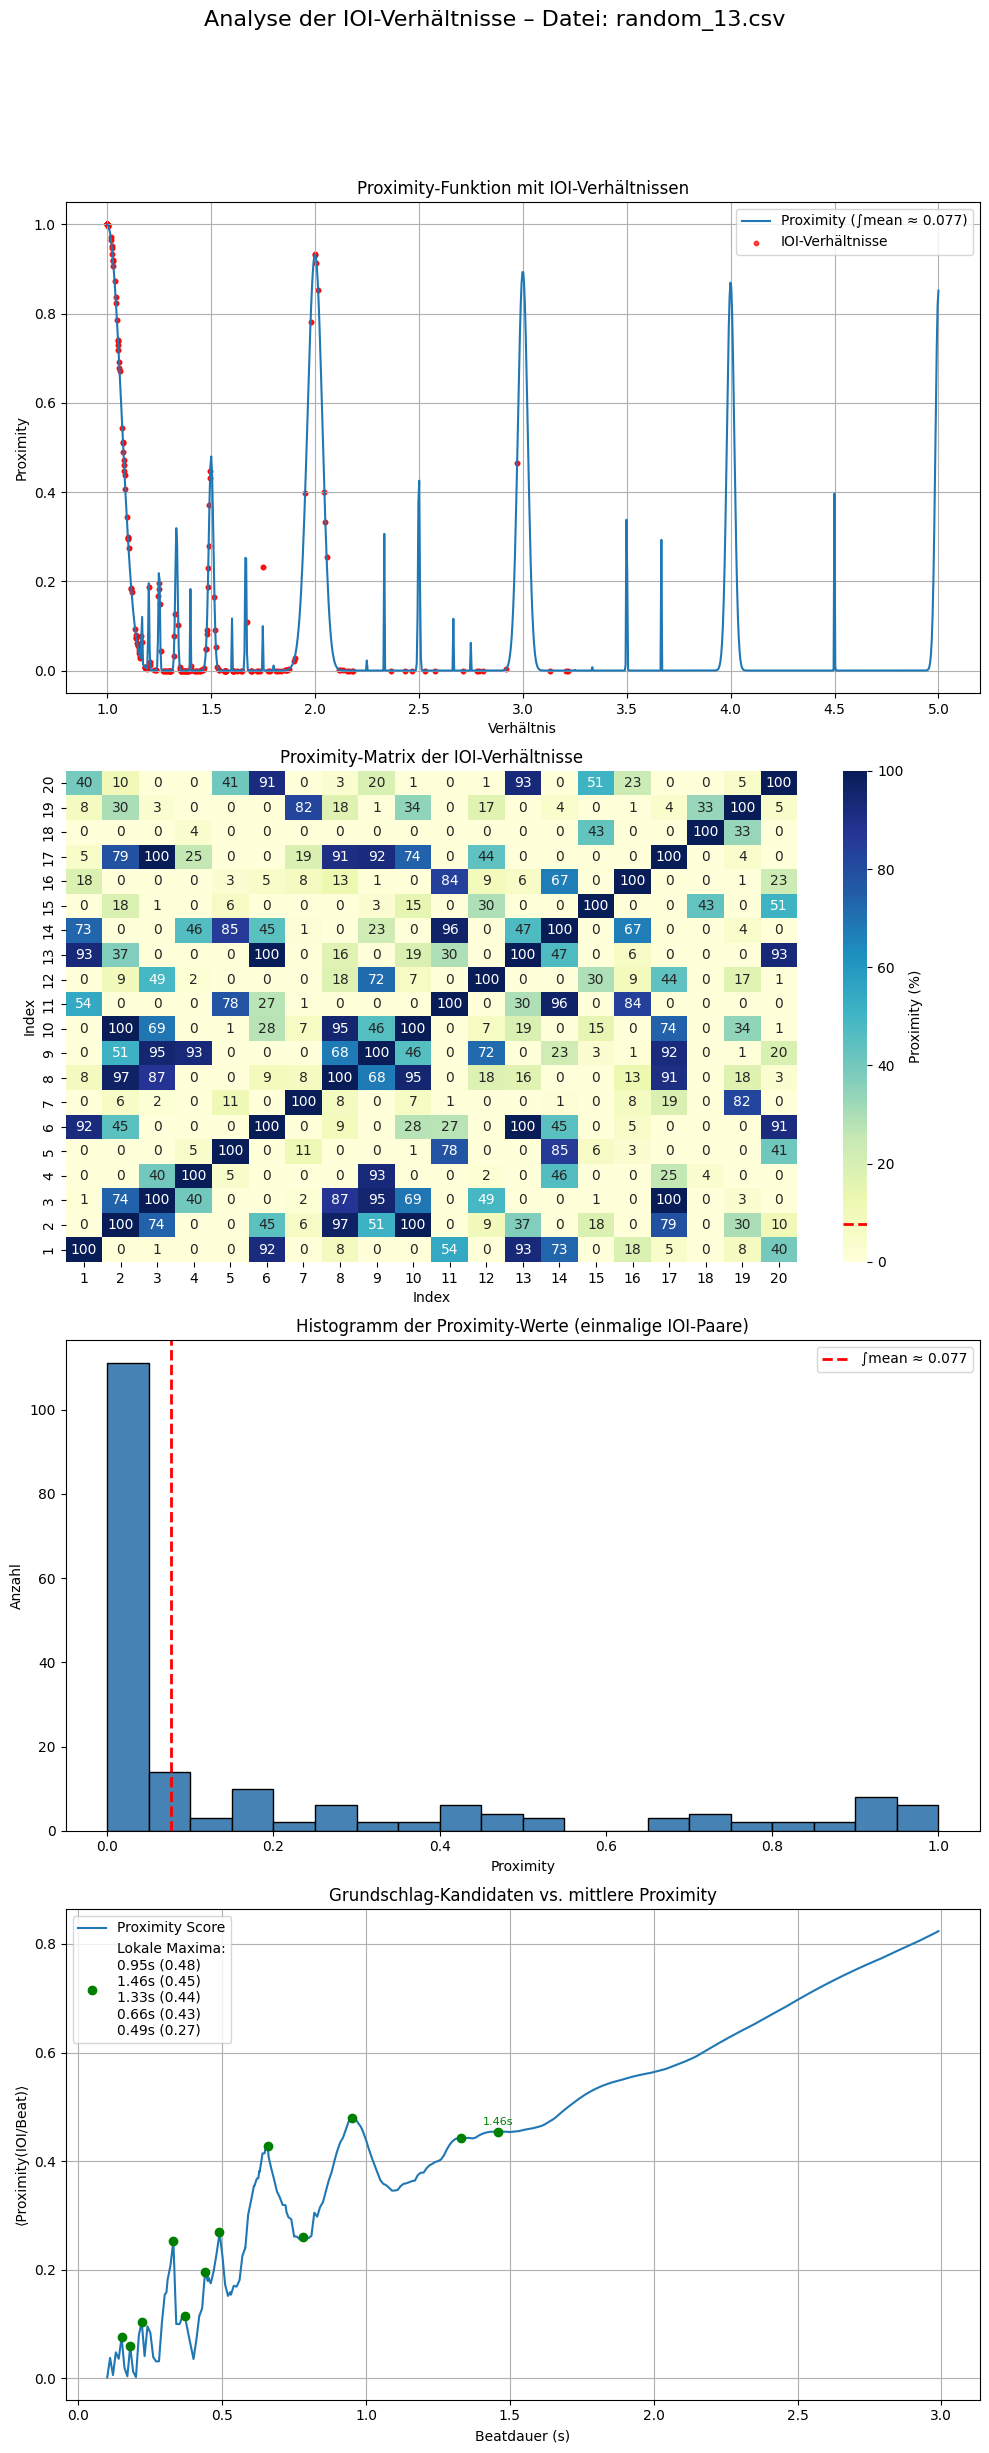

In [10]:
# === Analyse von IOI-Verhältnissen zur Beat-Detektion ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.integrate import simpson
from scipy.signal import argrelextrema

# === 1. Proximity-Funktion mit mehreren Frequenzen ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []

    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)

    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === 2. Hilfsfunktionen ===

def generate_beat_candidates_from_iois(iois, min_ioi=0.1, max_ioi=3.0, resolution=0.01):
    """Erzeugt Beat-Kandidaten aus IOIs und einem festen Raster."""
    candidates = set(ioi for ioi in iois if min_ioi <= ioi <= max_ioi)
    raster = np.arange(min_ioi, max_ioi, resolution)
    candidates.update(np.round(raster, 4))
    return sorted(candidates)

def score_for_beat(beat, iois, params):
    ratios = iois / beat
    prox_vals = proximity_max_freq(ratios, **params)
    return np.mean(prox_vals)

def find_local_maxima(candidates, scores, order=2):
    """Findet lokale Maxima der Score-Kurve."""
    indices = argrelextrema(np.array(scores), np.greater, order=order)[0]
    return [(candidates[i], scores[i]) for i in indices]

# === 3. Setup: Datei laden und Parameter definieren ===

filename = "random_13.csv"
num_beats = 20

base_dir = Path("../data/theoretical_sequences")
seq_dir = base_dir / f"synthetic_sequences_{num_beats}beats"
seq_path = seq_dir / filename

if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)
iois = df["IOI"].dropna().values

params = dict(
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=6,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)

# Verhältnis-Matrix
ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
proximity = proximity_max_freq(ratios, **params)

# Nur obere Dreieck-Werte (ohne Diagonale)
triu_indices = np.triu_indices_from(proximity, k=1)
proximity_unique = proximity[triu_indices]

# === 4. Beatkandidaten scoren ===

beat_candidates = generate_beat_candidates_from_iois(iois)
scores = [score_for_beat(beat, iois, params) for beat in beat_candidates]

local_maxima = find_local_maxima(beat_candidates, scores, order=2)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# === 5. Plots ===

fig, axes = plt.subplots(4, 1, figsize=(10, 24))
fig.suptitle(f"Analyse der IOI-Verhältnisse – Datei: {filename}", fontsize=16, y=1.02)

# -- Plot 1: Proximity-Funktion
x_range = np.linspace(1, 5, 1000)
y_curve = proximity_max_freq(x_range, **params)
mean_prox = simpson(y_curve, x_range) / (x_range[-1] - x_range[0])

axes[0].plot(x_range, y_curve, label=f"Proximity (∫mean ≈ {mean_prox:.3f})")
axes[0].scatter(ratios.flatten(), proximity.flatten(), color="red", s=10, alpha=0.7, label="IOI-Verhältnisse")
axes[0].set_title("Proximity-Funktion mit IOI-Verhältnissen")
axes[0].set_xlabel("Verhältnis")
axes[0].set_ylabel("Proximity")
axes[0].legend()
axes[0].grid(True)

# -- Plot 2: Heatmap der IOI-Proximities
heatmap = sns.heatmap(
    proximity * 100,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    xticklabels=list(range(1, len(iois) + 1)),
    yticklabels=list(range(1, len(iois) + 1)),
    cbar_kws={"label": "Proximity (%)"},
    vmin=0,
    vmax=100,
    ax=axes[1]
)
axes[1].invert_yaxis()
cbar = heatmap.collections[0].colorbar
cbar.ax.axhline(mean_prox * 100, color='red', linestyle='--', linewidth=2)
#cbar.ax.text(0.5, mean_prox * 100, f'{mean_prox*100:.1f}%', color='red', va='center', ha='center', fontsize=9, backgroundcolor='white')
axes[1].set_title("Proximity-Matrix der IOI-Verhältnisse")
axes[1].set_xlabel("Index")
axes[1].set_ylabel("Index")

# -- Plot 3: Histogramm der einmaligen Proximities
axes[2].hist(proximity_unique, bins=20, range=(0, 1), color='steelblue', edgecolor='black')
axes[2].axvline(mean_prox, color='red', linestyle='--', linewidth=2, label=f"∫mean ≈ {mean_prox:.3f}")
axes[2].legend()
axes[2].set_title("Histogramm der Proximity-Werte (einmalige IOI-Paare)")
axes[2].set_xlabel("Proximity")
axes[2].set_ylabel("Anzahl")

# -- Plot 4: Beat-Kandidaten & Score
axes[3].plot(beat_candidates, scores, label="Proximity Score")

# Lokale Maxima (grün markieren)
for beat, score in local_maxima:
    axes[3].plot(beat, score, 'o', color='green')

# Legende mit Top 5
top_labels = [f"{beat:.2f}s ({score:.2f})" for beat, score in local_maxima_top5]
axes[3].plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
axes[3].annotate(f"{beat:.2f}s", (beat, score), textcoords="offset points", xytext=(0, 5),
                 ha='center', fontsize=8, color='green')
axes[3].set_title("Grundschlag-Kandidaten vs. mittlere Proximity")
axes[3].set_xlabel("Beatdauer (s)")
axes[3].set_ylabel("⟨Proximity(IOI/Beat)⟩")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()

**Vergleich unterschiedlicher rhythmischer Sequenzen:**
Für eine Reihe synthetisch generierter Sequenzen aus dem Dataset *synthetic_sequences_20beats* wurden alle 
IOI-Verhältnisse berechnet, die Proximity-Werte ermittelt und die oberen Dreiecksmatrizen (ohne Diagonale) extrahiert.
Diese wurden anschließend nach Sequenztyp (z. B. "accelerando", "heterochron", "tempo_shift") gruppiert und in einem
Boxplot visualisiert.

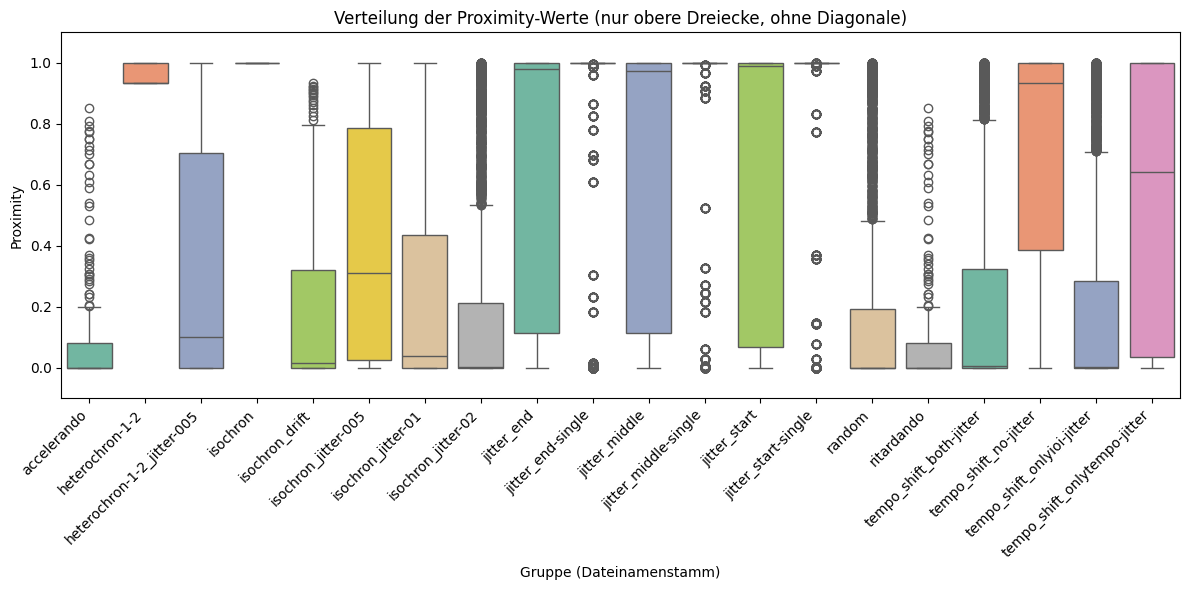

In [81]:
# Analysis of Proximity Values from Synthetic 20-Beats Sequences
# Boxplot of Proximity Values for Each Group

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# === Pfad zur 20-Beats Sequenz-Ordner ===
data_dir = Path("../data/theoretical_sequences/synthetic_sequences_20beats")
all_csv_files = list(data_dir.glob("*.csv"))

# === Container für Ergebnisse ===
all_results = []

# === Funktion zur Gruppierung aus Dateinamen extrahieren ===
def extract_group_name(filename):
    # Entferne Index vor ".csv", z.B. "_04.csv"
    return re.sub(r"_\d+(?=\.csv)", "", filename).replace(".csv", "")

# === Analyse-Funktion wiederverwenden ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []
    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)
    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === Haupt-Loop über alle Dateien ===
for file_path in all_csv_files:
    try:
        df = pd.read_csv(file_path)
        iois = df["IOI"].dropna().values
        if len(iois) < 2:
            continue  # überspringen, wenn zu wenig Daten

        ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
        proximity = proximity_max_freq(
            ratios,
            sharpness_base=10.0,
            sharpness_growth=2.0,
            decay=0.1,
            max_freq=4,
            weight_exponent=1.0,
            freq_sharpness_exp=1.0,
            norm_x=1.0,
            output_max=1.0
        )

        # Nur oberes Dreieck ohne Diagonale nehmen
        upper_triangle_values = proximity[np.triu_indices_from(proximity, k=1)]

        # Gruppe extrahieren
        group_name = extract_group_name(file_path.name)

        # Ergebnis speichern
        for val in upper_triangle_values:
            all_results.append({
                "group": group_name,
                "proximity": val
            })

    except Exception as e:
        print(f"Fehler bei Datei {file_path.name}: {e}")

# === In DataFrame umwandeln ===
results_df = pd.DataFrame(all_results)
results_df["group"] = pd.Categorical(results_df["group"], categories=sorted(results_df["group"].unique()), ordered=True)

# === Plot: Boxplot pro Gruppe ===
plt.figure(figsize=(12, 6))
sns.boxplot(data=results_df, x="group", y="proximity", hue="group", palette="Set2", legend=False)
plt.xticks(rotation=45, ha="right")
plt.ylim(-0.1, 1.1)
plt.title("Verteilung der Proximity-Werte (nur obere Dreiecke, ohne Diagonale)")
plt.xlabel("Gruppe (Dateinamenstamm)")
plt.ylabel("Proximity")
plt.tight_layout()
plt.show()


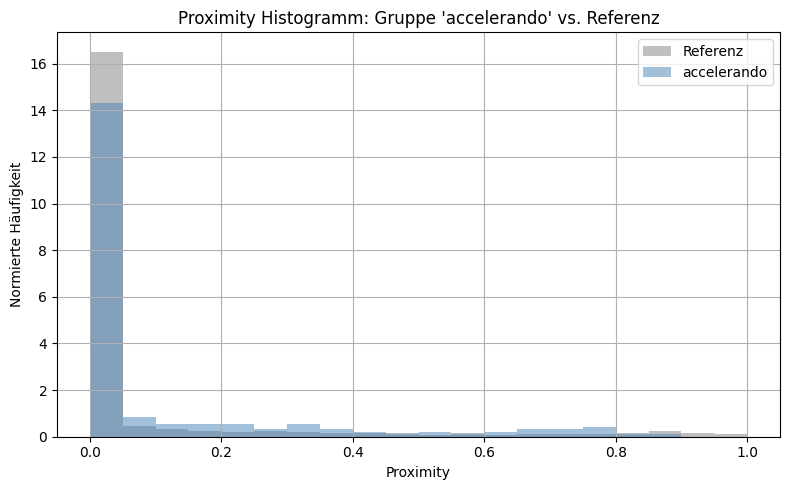

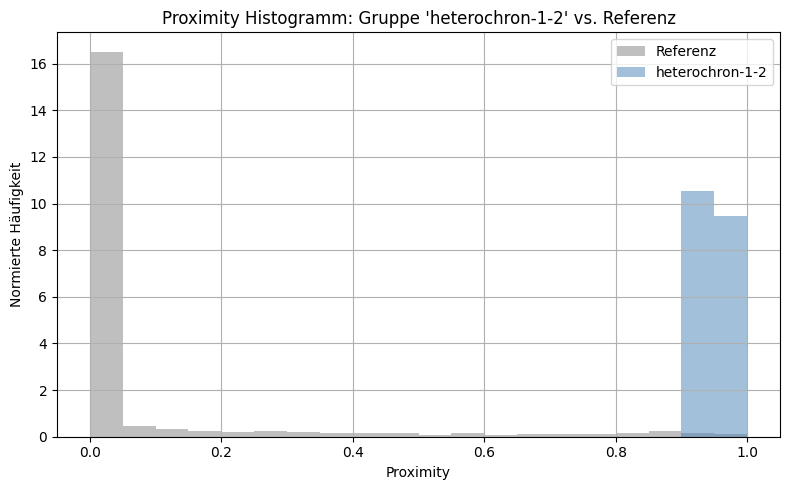

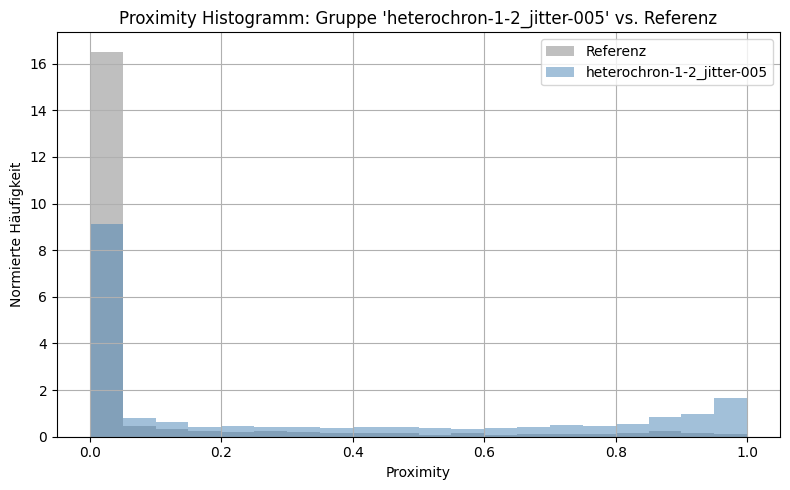

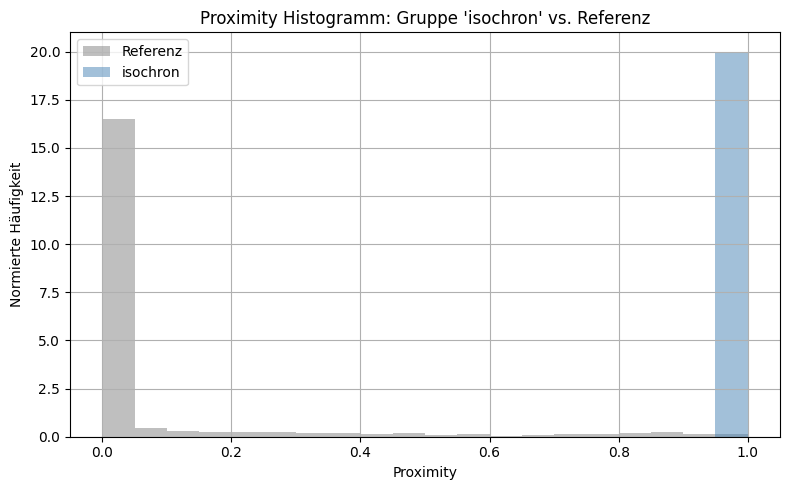

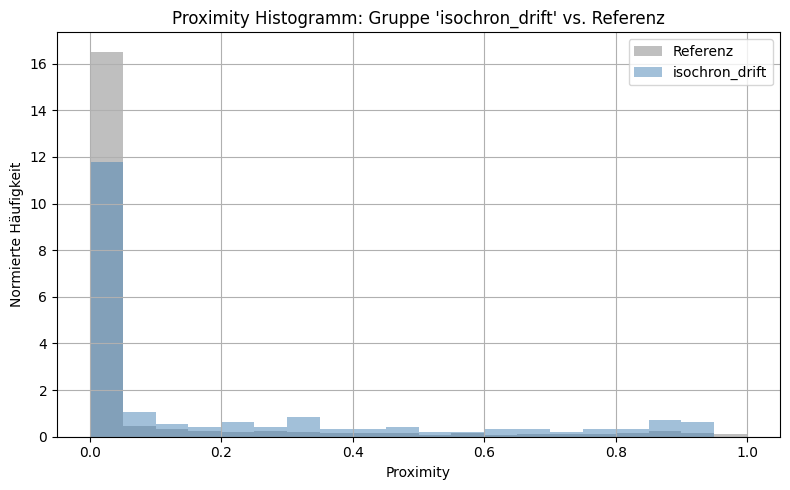

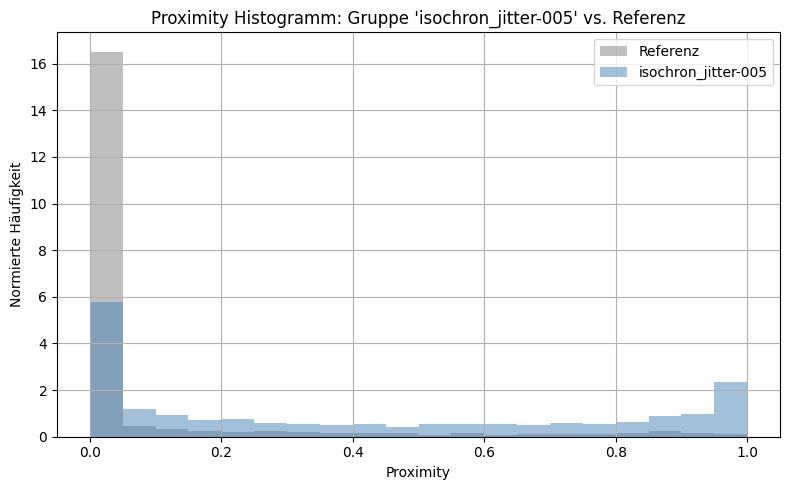

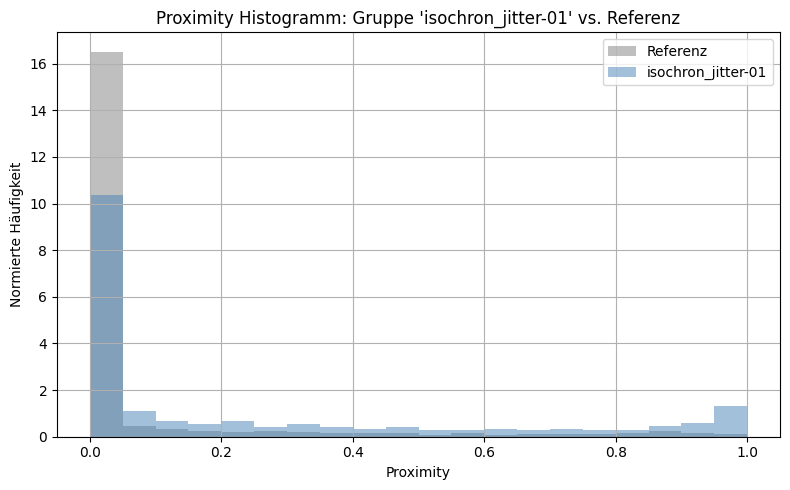

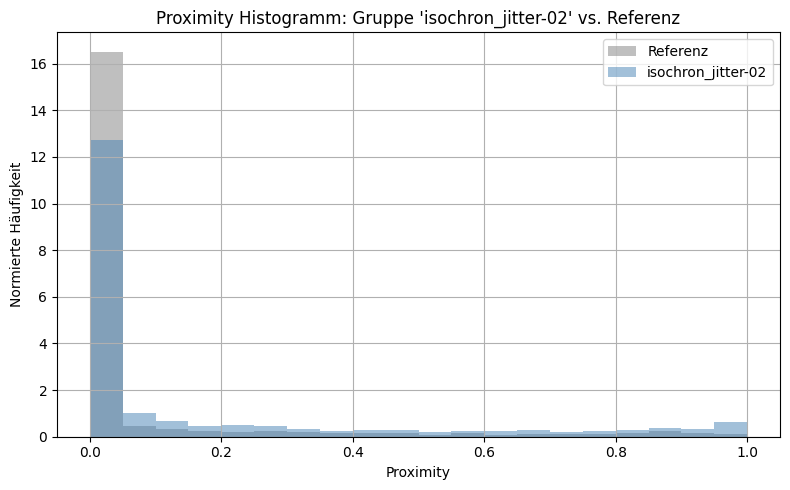

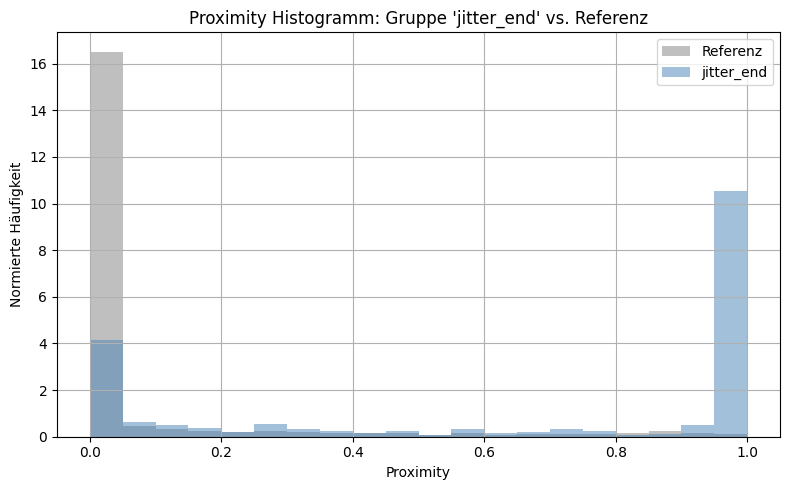

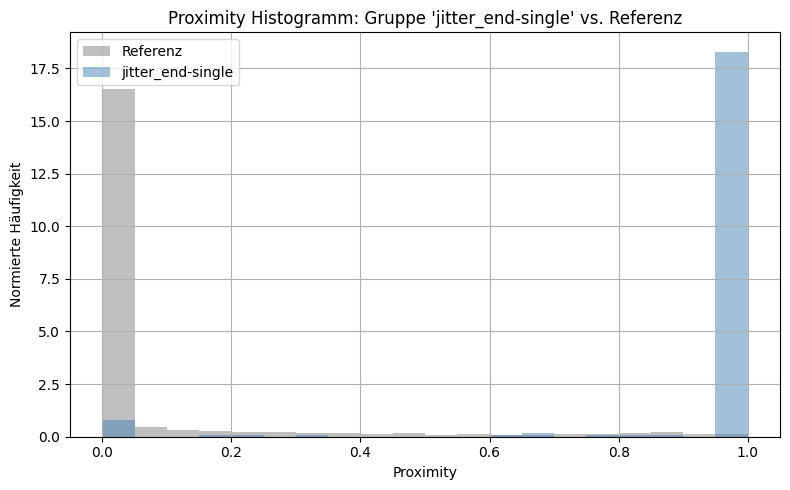

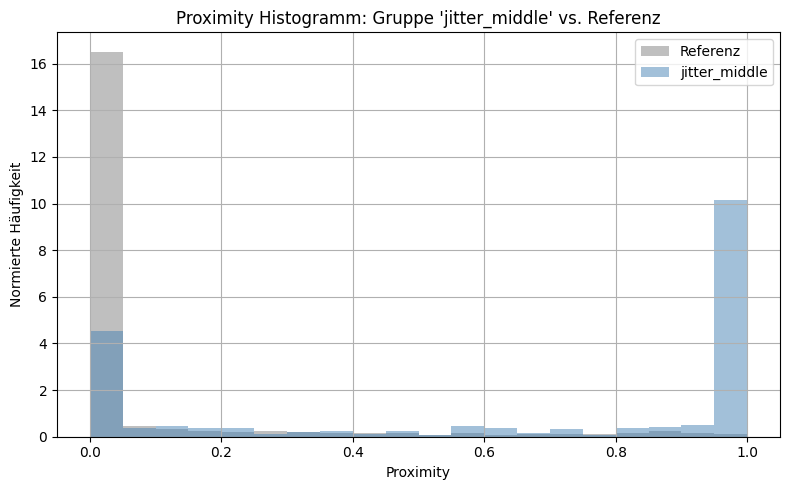

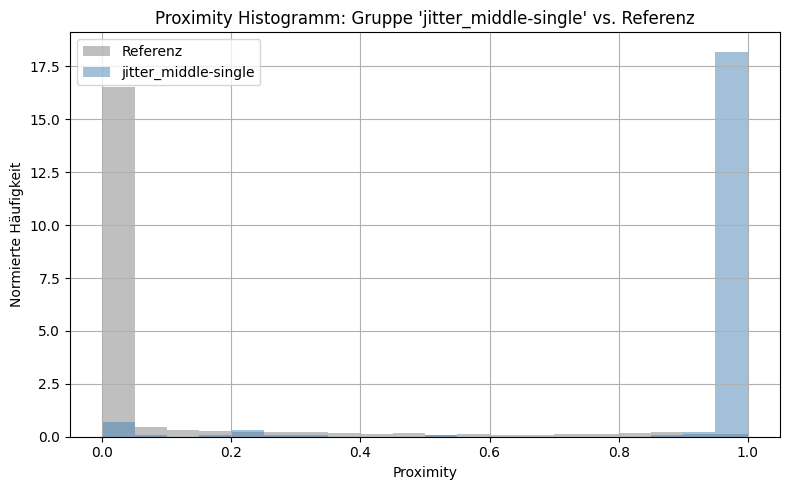

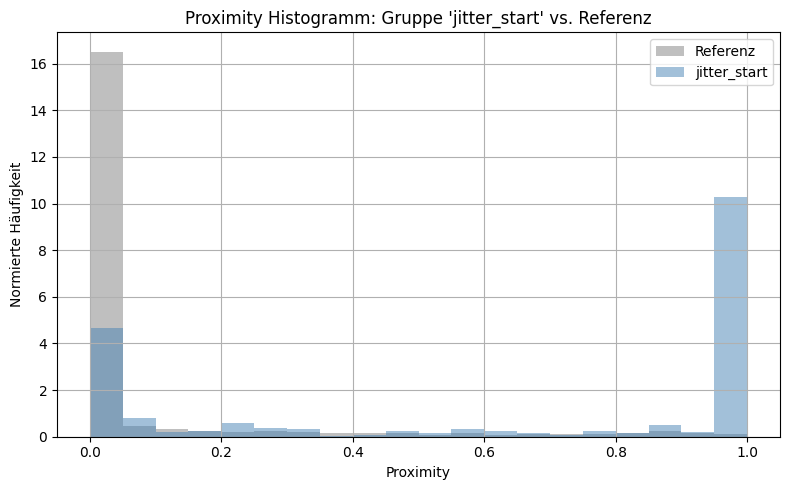

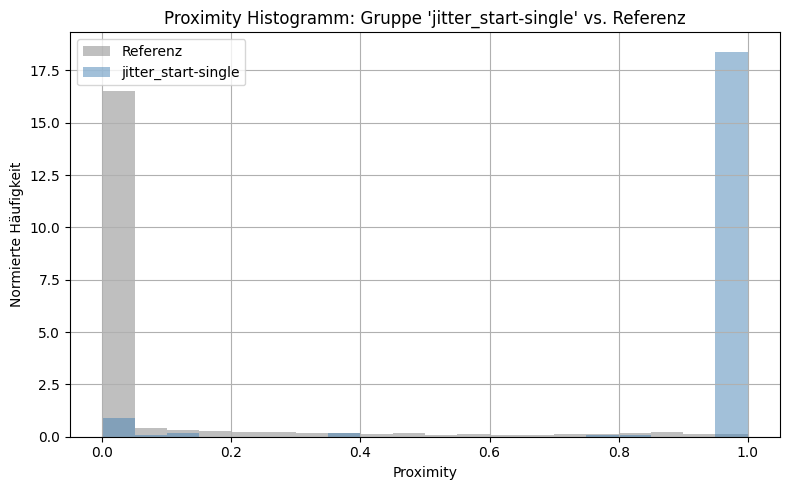

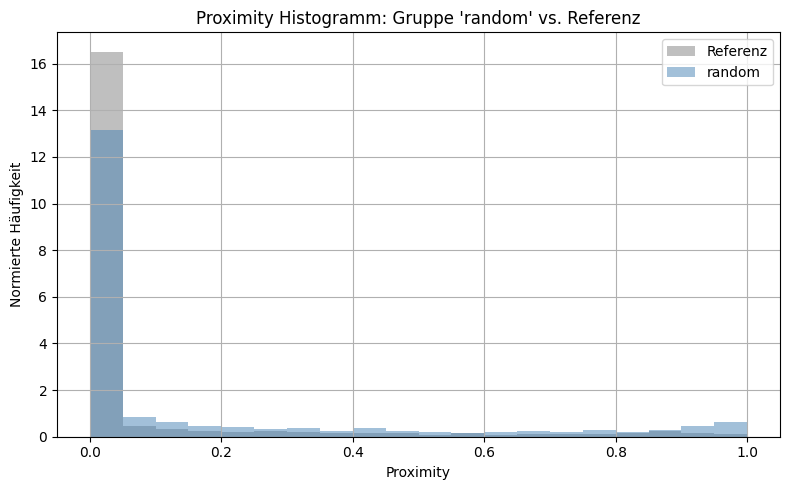

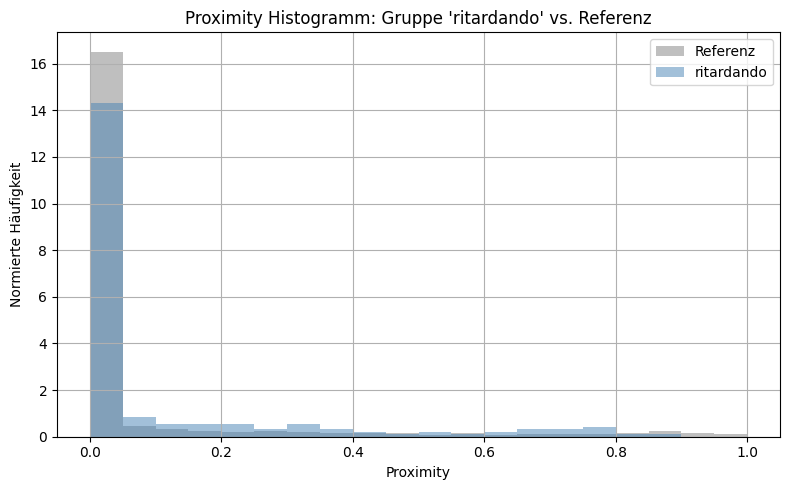

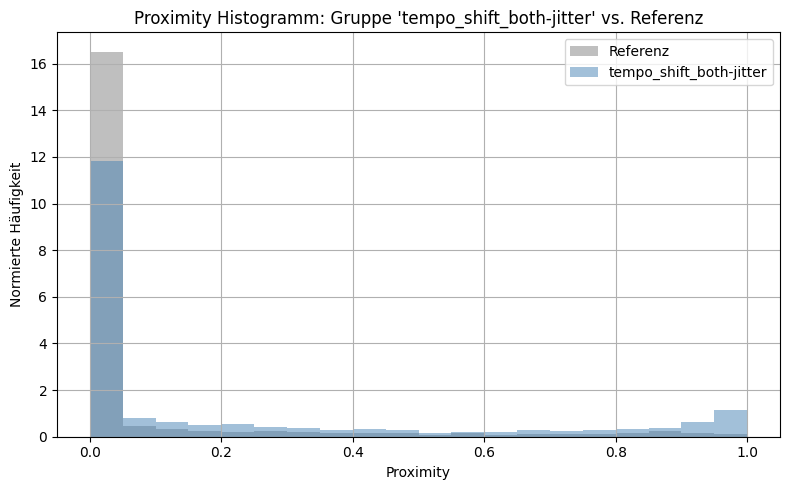

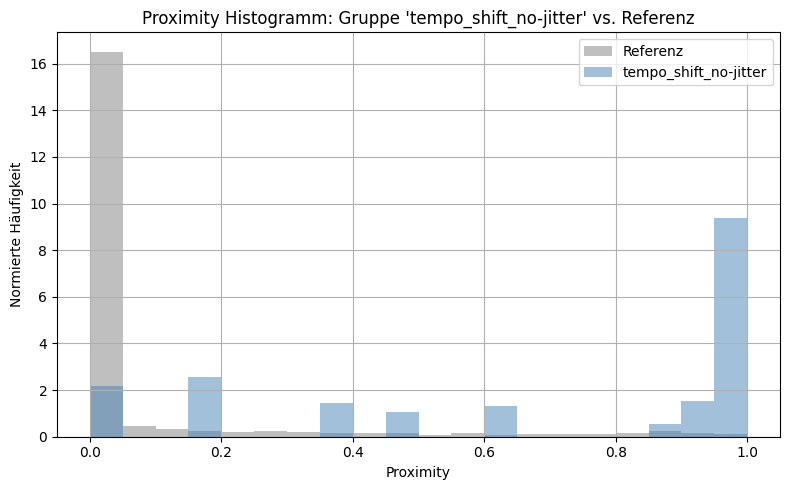

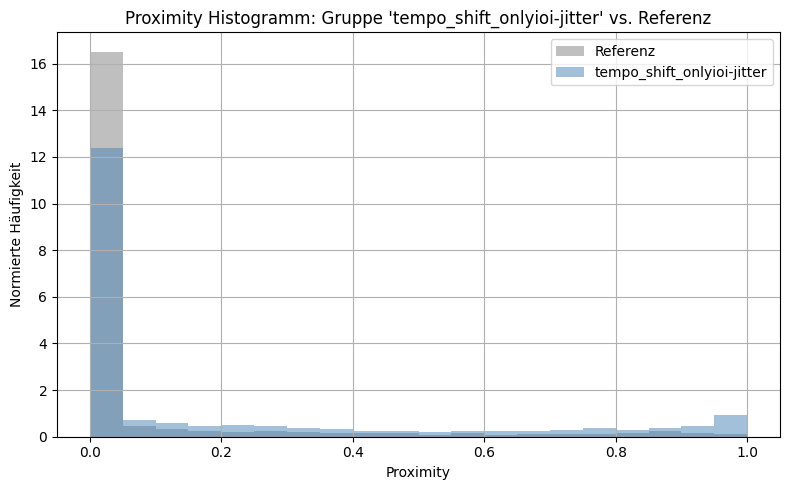

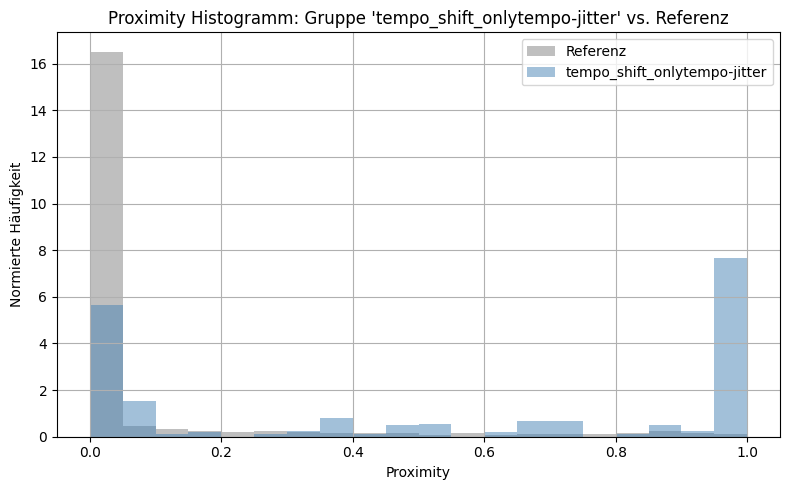

In [82]:
# Analysis of Proximity Values from Synthetic 20-Beats Sequences
# Histogram of Proximity Values for Each Group, compared with the Proximity-Functions Average

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# === Pfad zur 20-Beats Sequenz-Ordner ===
data_dir = Path("../data/theoretical_sequences/synthetic_sequences_20beats")
all_csv_files = list(data_dir.glob("*.csv"))

# === Container für Ergebnisse ===
all_results = []

# === Funktion zur Gruppierung aus Dateinamen extrahieren ===
def extract_group_name(filename):
    # Entferne Index vor ".csv", z.B. "_04.csv"
    return re.sub(r"_\d+(?=\.csv)", "", filename).replace(".csv", "")

# === Analyse-Funktion wiederverwenden ===
def proximity_max_freq(
    x,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
):
    x = np.array(x)
    all_freq_values = []
    for freq in range(1, max_freq + 1):
        weight = 1 / (freq ** weight_exponent)
        freq_sharpness_base = sharpness_base * (freq ** freq_sharpness_exp)
        freq_sharpness_growth = sharpness_growth * (freq ** freq_sharpness_exp)
        sharpness = freq_sharpness_base * (x ** freq_sharpness_growth)
        cos_term = ((1 + np.cos(2 * np.pi * freq * x)) / 2) ** sharpness
        peak_sharpness = freq_sharpness_base * (norm_x ** freq_sharpness_growth)
        peak_value = ((1 + np.cos(2 * np.pi * freq * norm_x)) / 2) ** peak_sharpness
        cos_term_normalized = cos_term / peak_value
        val = weight * cos_term_normalized / (x ** decay)
        all_freq_values.append(val)
    result = np.maximum.reduce(all_freq_values)
    max_at_norm_x = np.max([
        (1 / (freq ** weight_exponent)) * 1.0 / (norm_x ** decay)
        for freq in range(1, max_freq + 1)
    ])
    return result / max_at_norm_x * output_max

# === Haupt-Loop über alle Dateien ===
for file_path in all_csv_files:
    try:
        df = pd.read_csv(file_path)
        iois = df["IOI"].dropna().values
        if len(iois) < 2:
            continue  # überspringen, wenn zu wenig Daten

        ratios = np.array([[max(x, y) / min(x, y) for x in iois] for y in iois])
        proximity = proximity_max_freq(
            ratios,
            sharpness_base=10.0,
            sharpness_growth=2.0,
            decay=0.1,
            max_freq=4,
            weight_exponent=1.0,
            freq_sharpness_exp=1.0,
            norm_x=1.0,
            output_max=1.0
        )

        # Nur oberes Dreieck ohne Diagonale nehmen
        upper_triangle_values = proximity[np.triu_indices_from(proximity, k=1)]

        # Gruppe extrahieren
        group_name = extract_group_name(file_path.name)

        # Ergebnis speichern
        for val in upper_triangle_values:
            all_results.append({
                "group": group_name,
                "proximity": val
            })

    except Exception as e:
        print(f"Fehler bei Datei {file_path.name}: {e}")

# === In DataFrame umwandeln ===
results_df = pd.DataFrame(all_results)
results_df["group"] = pd.Categorical(results_df["group"], categories=sorted(results_df["group"].unique()), ordered=True)

# Hole alle Gruppen (außer Referenz)
groups = sorted(results_df["group"].unique())

# --- HISTOGRAM ---

# 1. Standard-x-Werte für die Referenz
x_ref = np.linspace(1, 5, 1000)
proximity_ref_values = proximity_max_freq(x_ref,
    sharpness_base=10.0,
    sharpness_growth=2.0,
    decay=0.1,
    max_freq=4,
    weight_exponent=1.0,
    freq_sharpness_exp=1.0,
    norm_x=1.0,
    output_max=1.0
)

# Histogramm-Parameter
bins = 20
range_hist = (0, 1)

for group in groups:
    plt.figure(figsize=(8,5))

    # Proximity Werte für die aktuelle Gruppe
    group_values = results_df.loc[results_df["group"] == group, "proximity"]

    # Histogramme plotten
    plt.hist(proximity_ref_values, bins=bins, range=range_hist, alpha=0.5, label="Referenz", color="gray", density=True)
    plt.hist(group_values, bins=bins, range=range_hist, alpha=0.5, label=group, color="steelblue", density=True)

    plt.title(f"Proximity Histogramm: Gruppe '{group}' vs. Referenz")
    plt.xlabel("Proximity")
    plt.ylabel("Normierte Häufigkeit")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
